# Домашнє завдання до модуля «Практичні приклади використання згорткових мереж»
## Забираємо датасет з Kaggle

In [1]:
import torch
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thepbordin/indoor-object-detection")

print("Path to dataset files:", path)

Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1


## Створюємо модель обгортку для YOLO
### Створюємо YAML для Ultralytics

In [2]:
import yaml
from pathlib import Path

def create_data_yaml(dataset_root: Path, src_yaml: Path | None = None, out_yaml: Path | None = None) -> Path:
    dataset_root = Path(dataset_root).resolve()
    src_yaml = (Path(src_yaml).resolve() if src_yaml else dataset_root / "data.yaml")
    if out_yaml is None:
        out_yaml = dataset_root / "data.fixed.yaml"
    out_yaml = Path(out_yaml).resolve()

    if not src_yaml.exists():
        raise FileNotFoundError(f"Не знайдено YAML: {src_yaml}")

    with src_yaml.open("r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    # Очікувана структура датасету з вашого логу:
    # {dataset_root}/train/images, {dataset_root}/valid/images (і, можливо, test/images)
    train_images = dataset_root / "train" / "images"
    val_images = dataset_root / "valid" / "images"
    test_images = dataset_root / "test" / "images"

    if not train_images.exists():
        raise FileNotFoundError(f"Не знайдено: {train_images}")
    if not val_images.exists():
        raise FileNotFoundError(f"Не знайдено: {val_images}")

    # Правильний формат для Ultralytics:
    # - можна задати 'path' як root
    # - а train/val/test як відносні шляхи від root
    data["path"] = str(dataset_root)
    data["train"] = "train/images"
    data["val"] = "valid/images"
    if test_images.exists():
        data["test"] = "test/images"
    else:
        # не змушуємо тест існувати
        data.pop("test", None)

    with out_yaml.open("w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    return out_yaml.absolute()


def get_gpu():
    if torch.cuda.is_available():
        return "0"
    elif torch.backends.mps.is_available():
        return "mps"
    else:
        return None

### Обгортаємо набір гіперпараметрів у дата клас

In [3]:
from dataclasses import dataclass


@dataclass
class HyperParameters:
    model: str
    data: str
    lr0: float
    lrf: float
    weight_decay: float
    optimizer: str = "SGD"
    epochs: int = 10
    imgsz: int = 640
    batch: int = 16
    workers: int = 0

### Створюємо власну модель обгортку для YOLO

In [4]:
class YOLOTrainer:
    """
    YOLOTrainer — тонка “обгортка” (facade) над `ultralytics.YOLO`, яка:
      1) тримає в одному місці модель + набір гіперпараметрів (HyperParameters),
      2) дає стабільний мінімальний API: `train()`, `val()`, `export()`,
      3) ізолює решту ноутбука/пайплайна від деталей Ultralytics (імен аргументів, формату виклику).

    Архітектурна ідея:
      - `HyperParameters` = конфігурація (що саме тренуємо і як).
      - `YOLOTrainer` = виконання (ініціалізація моделі + запуск train/val/export).
      - `HyperParametersOptimizer` (нижче) = зовнішній оркестратор, який:
          * генерує різні `HyperParameters` (через Optuna),
          * створює `YOLOTrainer`,
          * запускає навчання/валідацію,
          * оптимізує метрику (наприклад, mAP50).

    Важливо:
      - Тренування викликається через `self.yolo_model.train(**asdict(...))`.
        Це означає, що назви полів у `HyperParameters` мають збігатися з аргументами Ultralytics.
      - `val()` повертає об’єкт метрик Ultralytics (зокрема `metrics.box.map50`), який
        використовується як цільова функція при HPO.
      - `export()` тут експортує *останній* навчений чекпойнт (типово best.pt у run-dir),
        у формат ONNX для інференсу поза Python/PyTorch.
    """

    def __init__(self, hyper_parameters: HyperParameters):
        # "Двигун" — реальний об’єкт Ultralytics YOLO, який вміє train/val/export.
        # На вході: шлях/назва pretrained ваг (наприклад "yolov9e.pt").
        self.yolo_model = YOLO(hyper_parameters.model)

        # "Конфіг" — dataclass з параметрами тренування/валідації.
        # Ми зберігаємо його, щоб:
        #  - передавати в `.train()` одним пакетом,
        #  - мати доступ до `data/imgsz/...` під час `val()` та `export()`.
        self.hyper_parameters = hyper_parameters

    def train(self):
        # Запуск навчання Ultralytics.
        # asdict() перетворює dataclass у dict, щоб можна було розпакувати як kwargs.
        # Очікувано тут пролітають: model, data, lr0, lrf, weight_decay, optimizer, epochs, imgsz, batch, workers.
        self.yolo_model.train(**asdict(self.hyper_parameters))

    def val(self):
        # Валідація моделі на датасеті, вказаному в YAML (self.hyper_parameters.data).
        # Повертає об’єкт метрик, з якого потім дістають:
        #  - metrics.box.map50, metrics.box.mp, metrics.box.mr тощо.
        return self.yolo_model.val(data=self.hyper_parameters.data)

    def export(self):
        # Експорт моделі для продакшн/інференсу.
        # Тут обрано ONNX, бо це універсальний формат (можна дивитись у Netron, запускати через різні рантайми).
        # imgsz важливий: задає вхідний розмір, під який формується обчислювальний граф.
        # half/int8/simplify/nms вимкнені — більш передбачувана сумісність “з коробки”.
        self.yolo_model.export(
            format='onnx',  # openvino, onnx, engine, tflite
            imgsz=self.hyper_parameters.imgsz,
            half=False,
            int8=False,
            simplify=False,
            nms=False,
        )

Особливості архітектури я описав у коментарях в коді самої моделі. Ця частина є лише фасадом для використання у основному коді. Конфігурація моделі виконується в класі `HyperParameters`, де встановлюються параметри, які впливають на архітектуру моделі та її поведінку. Використання цього фасаду дозволяє зберегти основний код чистим і безпосередньої залежності від деталей реалізації моделі.

### Клас - конфігуратор для підбору гіперпараметрів моделі

Архітектуру даного конфігуратора опишу в коментарях до коду. Клас `HyperParametersOptimizer` використовується для оптимізації гіперпараметрів моделі за допомогою бібліотеки Optuna. Він містить метод `objective`, який використовується для визначення метрики для оптимізації, а також метод `optimize`, який запускає процес оптимізації.

In [5]:
from dataclasses import asdict
import gc
import optuna
from pathlib import Path
from ultralytics import YOLO


class HyperParametersOptimizer:
    """
    HyperParametersOptimizer — “оркестратор” підбору гіперпараметрів (HPO) для YOLO через Optuna.

    Роль у загальній архітектурі ноутбука:
      - `create_data_yaml(...)` готує коректний YAML для Ultralytics (train/val шляхи).
      - `HyperParameters` описує простір параметрів як dataclass (конфіг).
      - `YOLOTrainer` виконує train/val/export (виконавець).
      - `HyperParametersOptimizer` керує циклом оптимізації:
          1) генерує кандидата параметрів (trial),
          2) запускає тренування (через YOLOTrainer),
          3) оцінює метрику на валідації,
          4) повертає значення метрики назад у Optuna,
          5) акуратно обробляє невдалі запуски (OOM/NaN) і чистить ресурси між trial-ами.

    Терміни (важливо не плутати):
      - `n_trials` (у цьому класі) — скільки спроб Optuna зробить (скільки різних конфігів перевіримо).
      - `epochs` (у `HyperParameters`) — скільки епох тренувати модель у межах одного trial.
    """

    def __init__(self, dataset_path: Path, n_trials: int = 10):
        # `dataset_path` — корінь датасету (папка, де лежать train/valid/...).
        self.dataset_path = dataset_path

        # `n_trials` — кількість trial-ів Optuna (скільки спроб різних гіперпараметрів зробимо).
        self.n_trials = n_trials

        # Генеруємо “виправлений” data.yaml, який точно підходить Ultralytics (path/train/val/test).
        # Зберігаємо як строку, бо Ultralytics очікує шлях у вигляді str.
        self.yaml_path = str(create_data_yaml(self.dataset_path))

    def objective(self, trial):
        """
        Цільова функція Optuna.

        На кожному `trial`:
          1) формуємо search space (epochs/imgsz/batch/...),
          2) створюємо `HyperParameters`,
          3) запускаємо `YOLOTrainer.train()` та `YOLOTrainer.val()`,
          4) повертаємо скаляр, який Optuna буде максимізувати (тут: mAP50).

        Важливо:
          - Повертати треба саме число (float).
          - Все, що “впало” через OOM/NaN, краще `TrialPruned`, а не Exception — так Optuna
            продовжить оптимізацію й не втратить прогрес.
        """

        PRETRAINED_WEIGHTS_V8_TO_V10_DETECT = [
            # YOLOv8 (Detect)
            "yolov8s.pt",
            "yolov8m.pt",
            "yolov8l.pt",

            # YOLOv9 (Detect)
            "yolov9c.pt",
            "yolov9e.pt",

            # YOLOv10 (Detect)
            "yolov10s.pt",
            "yolov10m.pt",
            "yolov10b.pt",
            "yolov10l.pt",
        ]

        # 1) Search space (простір параметрів), з якого Optuna вибирає значення:
        data = str(self.yaml_path)

        # `epochs` — кількість епох навчання *конкретного trial* (тобто для однієї моделі).
        epochs = trial.suggest_int("epochs", 10, 40)

        imgsz = trial.suggest_categorical("imgsz", [512, 640])
        batch = trial.suggest_categorical("batch", [8, 16])
        workers = trial.suggest_int("workers", 0, 2)

        device = get_gpu()
        name = f"trial_{trial.number}"

        model_name = trial.suggest_categorical("model", PRETRAINED_WEIGHTS_V8_TO_V10_DETECT)

        lr0 = trial.suggest_float("lr0", 1e-5, 3e-2, log=True)
        lrf = trial.suggest_float("lrf", 0.01, 0.3)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

        amp = False
        optimizer = trial.suggest_categorical("optimizer", ["SGD", "AdamW", "RAdam"])

        train_params = HyperParameters(
            model=model_name,
            data=data,
            lr0=lr0, lrf=lrf,
            weight_decay=weight_decay,
            optimizer=optimizer,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            workers=workers
        )

        model = YOLOTrainer(train_params)

        try:
            model.train()
            metrics = model.val()
            return float(metrics.box.map50)

        except torch.OutOfMemoryError:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
            gc.collect()
            raise optuna.TrialPruned("CUDA OOM: trial pruned")

        except RuntimeError as e:
            msg = str(e)
            if "NaN/Inf weights" in msg or "nan" in msg.lower() or "inf" in msg.lower():
                raise optuna.exceptions.TrialPruned(msg)
            raise

        finally:
            if model is not None:
                del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    def optimize(self):
        """
        Запускає Optuna study і повертає найкращі знайдені параметри (dict).

        `n_trials=self.n_trials` — кількість спроб (trial-ів) у цьому запуску оптимізації.
        """
        study = optuna.create_study(direction="maximize")
        study.optimize(self.objective, n_trials=self.n_trials)
        return study.best_params



Варто зазначити, що наш клас підбору гіперпараметрів (HPO) за допомогою Optuna дозволяє швидко і ефективно знайти найкращі гіперпараметри для YOLO моделі. Оптимізація ведеться за допомогою цільової функції `objective`, яка використовує Optuna для генерації кандидатів гіперпараметрів та оцінює їх на основі метрики mAP50. Клас також обробляє невдалі запуски (OOM/NaN) і чистить ресурси між trial-ами, щоб забезпечити стабільність оптимізації. Також ми обробляємо випадки самогубчих гіперпараметрів, котрі убивають модель або викликають переповнення в памʼяті **CUDA**. У цьому випадку ми виводимо помилку та пропускаємо спробу.

### Запускаємо пошук найкращих гіперпараметрів для моделі YOLO
Ініціалізуємо наш клас підбору гіперпараметрів (HPO) для YOLO моделі на 20 спроб. Як бачимо, *Optuna* автоматично обробляє невдалі запуски (OOM/NaN) і пропускає їх, щоб не вплинути на результати оптимізації.

In [6]:
hp_optimizer = HyperParametersOptimizer(Path(path).absolute(), n_trials=20)
best_params = hp_optimizer.optimize()

[I 2025-12-31 11:58:53,598] A new study created in memory with name: no-name-b4986191-68ad-41f9-aef1-19b5aeb3c912


New https://pypi.org/project/ultralytics/8.3.243 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.242 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1/data.fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=31, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=3.158835425203902e-05, lrf=0.019822541203772758, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

/home/ubuntu/.virtualenvs/WoolfDataScience/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2025/12/31 11:59:04 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Ultralytics' does not exist. Creating a new experiment.
2025/12/31 11:59:05 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


MLflow: logging run_id(0285f15332e24c27b3f936238d83bcc1) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 1 dataloader workers
Logging results to /tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train3
Starting training for 31 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/31      5.19G      1.557      2.526      1.456         60        640: 100% ━━━━━━━━━━━━ 127/127 2.5it/s 49.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.0it/s 3.7s0.2s
                   all        230       1289      0.574      0.244      0.252      0.143

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/31      6.31G      1.423      1.861       1.34         32        640: 100% ━━━━━━━━━━━━ 127/127

[I 2025-12-31 12:27:29,034] Trial 0 finished with value: 0.5410337361979637 and parameters: {'epochs': 31, 'imgsz': 640, 'batch': 8, 'workers': 1, 'model': 'yolov8l.pt', 'lr0': 3.158835425203902e-05, 'lrf': 0.019822541203772758, 'weight_decay': 0.0003262552710214909, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.5410337361979637.


...

[I 2025-12-31 18:29:57,852] Trial 18 pruned. CUDA OOM: trial pruned


New https://pypi.org/project/ultralytics/8.3.244 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.242 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1/data.fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=16, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00153309206894157, lrf=0.07630352574144281, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

2025/12/31 18:30:00 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


MLflow: logging run_id(d3b01d2d7afc41f3aaadfc032bf41869) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
WARNING ⚠️ MLflow: Failed to initialize: Changing param values is not allowed. Param with key='model' was already logged with value='yolov9e.pt' for run ID='d3b01d2d7afc41f3aaadfc032bf41869'. Attempted logging new value 'yolov8s.pt'.
WARNING ⚠️ MLflow: Not tracking this run
Image sizes 640 train, 640 val
Using 1 dataloader workers
Logging results to /tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train22
Starting training for 16 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
: 0% ──────────── 0/127  0.0s


[I 2025-12-31 18:30:01,296] Trial 19 pruned. CUDA OOM: trial pruned


In [9]:
print(f"Найкращі гіперпараметри: {best_params}")

Найкращі гіперпараметри: {'epochs': 38, 'imgsz': 640, 'batch': 8, 'workers': 0, 'model': 'yolov9e.pt', 'lr0': 0.005222375520581899, 'lrf': 0.06305787273269099, 'weight_decay': 0.0007099112021473994, 'optimizer': 'SGD'}


## Тренуємо найкращу модель з найкращими гіперпараметрами

In [12]:
final_model = YOLOTrainer(HyperParameters(**best_params, data=str(Path(path).absolute() / "data.fixed.yaml")))
final_model.train()

New https://pypi.org/project/ultralytics/8.3.245 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.242 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1/data.fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=38, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005222375520581899, lrf=0.06305787273269099, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model

2026/01/01 12:47:34 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


MLflow: logging run_id(d3b01d2d7afc41f3aaadfc032bf41869) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
WARNING ⚠️ MLflow: Failed to initialize: Changing param values is not allowed. Param with key='epochs' was already logged with value='37' for run ID='d3b01d2d7afc41f3aaadfc032bf41869'. Attempted logging new value '38'.
WARNING ⚠️ MLflow: Not tracking this run
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25
Starting training for 38 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/38        11G      1.754      3.173      1.746         32        640: 100% ━━━━━━━━━━━━ 127/127 1.0it/s 2:030.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.7it/s 9.0s0.6s
            

### Експортуємо найкращу модель

In [13]:
final_model.export()

Ultralytics 8.3.242 🚀 Python-3.12.3 torch-2.9.1+cu128 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv9e summary (fused): 279 layers, 57,384,110 parameters, 0 gradients, 189.2 GFLOPs

PyTorch: starting from '/tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (111.8 MB)
requirements: Ultralytics requirement ['onnx>=1.12.0,<2.0.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/18.1 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 236.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to ta

/home/ubuntu/.virtualenvs/WoolfDataScience/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: export success ✅ 10.5s, saved as '/tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25/weights/best.onnx' (219.3 MB)

Export complete (15.1s)
Results saved to /tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25/weights
Predict:         yolo predict task=detect model=/tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/tmp/pycharm_project_865/home_works/deep_learning/runs/detect/train25/weights/best.onnx imgsz=640 data=/home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1/data.fixed.yaml  
Visualize:       https://netron.app


## Валідуємо нашу найкращу модель та виводимо результати

In [14]:
model_evaluation = final_model.val()

Ultralytics 8.3.242 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9e summary (fused): 279 layers, 57,384,110 parameters, 0 gradients, 189.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2267.6±1047.7 MB/s, size: 153.0 KB)
val: Scanning /home/ubuntu/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1/valid/labels.cache... 230 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 532.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.2it/s 12.7s0.8s
                   all        230       1289      0.631      0.534       0.55      0.378
                  door         63         97      0.582      0.619      0.614      0.387
           cabinetDoor         99        765      0.791      0.792      0.842      0.492
      refrigeratorDoor         85        192      0.839      0.802      0.856      0.585
                window         39         91      0.492 

### Виводимо метрики: середня точність, recall, mAP50

In [16]:
P = float(model_evaluation.box.mp)  # mean precision
R = float(model_evaluation.box.mr)  # mean recall
F1 = 2 * P * R / (P + R + 1e-16)

print(f"Середня точність моделі: {F1:.4f}")
print(f"Середній recall моделі: {R:.4f}")
print(f"Середня точність визначення по рамці 50% (mAP50): {model_evaluation.box.map50:.4f}")

Середня точність моделі: 0.5782
Середній recall моделі: 0.5338
Середня точність визначення по рамці 50% (mAP50): 0.5505


Як бачимо, середня точність моделі по всіх метриках становить трішки понад 55%.

### Виводимо графіки прогресу тренування

In [17]:
from matplotlib import pyplot as plt
import pandas as pd


def draw_learning_progress(model_trainer: YOLOTrainer):
    original_model = model_trainer.yolo_model
    trainer = getattr(original_model, "trainer", None)
    if trainer is None:
        print("У цього об'єкта немає trainer (можливо, це модель, яку просто завантажили з .pt).")
    else:
        # у різних версіях може бути save_dir або в args
        run_dir = getattr(trainer, "save_dir", None) or getattr(getattr(trainer, "args", None), "save_dir", None)
        train_csv = Path(run_dir) / "results.csv"
        df = pd.read_csv(train_csv)
        # приклад: графік val mAP50-95 (назва може трохи відрізнятися)
        for col in ["metrics/mAP50-95(B)", "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"]:
            if col in df.columns:
                plt.plot(df["epoch"], df[col], label=col)

        plt.xlabel("epoch")
        plt.legend()
        plt.grid(True)
        plt.show()

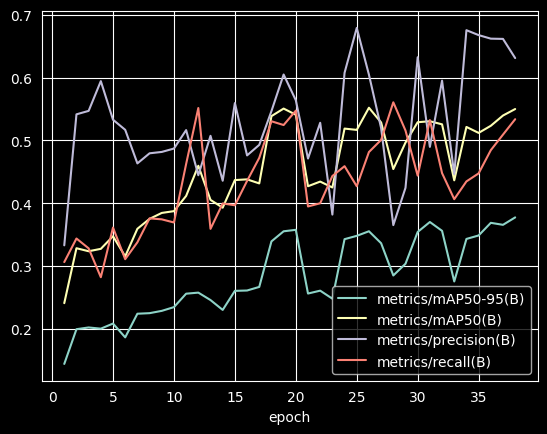

In [18]:
draw_learning_progress(final_model)

Як бачимо з візуалізації, крива прогресу у всіх метриках є синусоїдо-подібною. Тобто, підйом - спуск. Попри таку структуру, в певній точці крива досягає свого екстремуму. Усі метрики досягають екстремуму десь на епохах 20 - 27, після чого показники спадають і вже не досягають екстремуму.
Як показують спроби з різними гіперпараметрами через **Optuna**, найкраще спрацював оптимізатор **SGD**, а найкращою версією моделі - **YOLOv9e**. Навіть версія **10** виявилась не такою ефективною.

### Виводимо графіки точності по класам

In [23]:
def draw_precisions_by_class(model_val):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1) Дістаємо precision по класах з model_val.box
    box = getattr(model_val, "box", None)
    if box is None:
        raise ValueError("У model_val немає атрибута 'box'. Перевірте, що це результат model.val().")

    # У різних версіях Ultralytics назви можуть відрізнятися.
    # Найчастіше precision по класах — це box.p (масив довжини num_classes).
    per_class_p = None
    for attr in ("p", "precision", "mp"):  # mp інколи означає mean precision, але пробуємо як fallback
        if hasattr(box, attr):
            candidate = getattr(box, attr)
            if candidate is not None:
                per_class_p = np.asarray(candidate)
                break

    if per_class_p is None:
        # Діагностичне повідомлення замість "пандас зламався"
        available = [a for a in dir(box) if not a.startswith("_")]
        raise ValueError(
            "Не вдалося знайти precision по класах у model_val.box. "
            f"Доступні атрибути box: {available}"
        )

    # Якщо це скаляр (mean precision), а не масив по класах — теж не те
    if per_class_p.ndim == 0:
        raise ValueError(
            "model_val.box містить лише скалярний precision (середнє), а не значення по класах. "
            "Потрібні per-class метрики (масив)."
        )

    # 2) Імена класів
    names = getattr(model_val, "names", None)
    if isinstance(names, dict):
        class_ids = list(range(len(per_class_p)))
        class_names = [names.get(i, str(i)) for i in class_ids]
    elif isinstance(names, (list, tuple)):
        class_names = list(names)[: len(per_class_p)]
    else:
        class_names = [str(i) for i in range(len(per_class_p))]

    # 3) DataFrame + графік
    df = pd.DataFrame({"class": class_names, "precision": per_class_p.astype(float)})
    ax = df.plot(x="class", y="precision", kind="bar", legend=False, figsize=(10, 4))
    ax.set_xlabel("Class")
    ax.set_ylabel("Precision")
    ax.set_title("Precision by class")
    plt.tight_layout()
    plt.show()

    return df

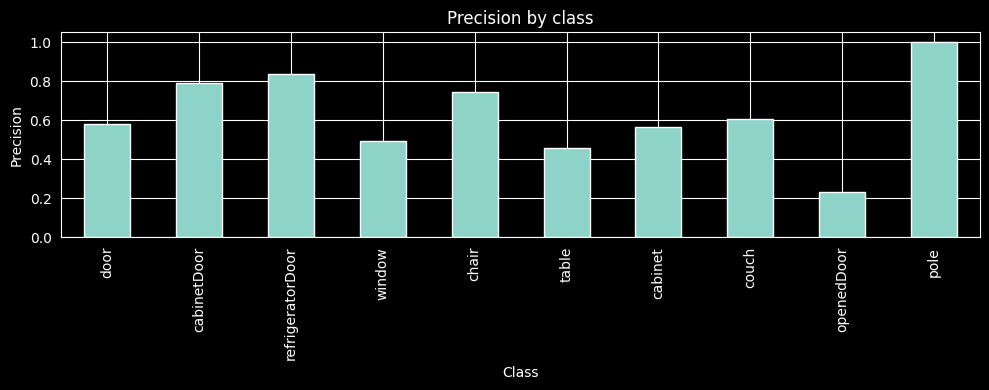

,class,precision
0,door,0.582316
1,cabinetDoor,0.791137
2,refrigeratorDoor,0.838600
3,window,0.492174
4,chair,0.744077
5,table,0.455341
6,cabinet,0.563596
7,couch,0.606069
8,openedDoor,0.232334
9,pole,1.000000


In [24]:
draw_precisions_by_class(model_evaluation)

Як бачимо зі всього попереднього аналізу, ефективність тренування чітко корелює з кількістю картинок у тренувальному наборі даних. Звісно, ми не можемо сказати нічого конкретного про класи, де є присутня 1 або кілька картинок (**couch**, **pole**).